# Loan Approval Prediction Model

### **Loan approval is one of the most important decision-making processes in the banking sector. Financial institutions evaluate several factors such as annual income, credit history, employment status, education level, loan amount, assets, and repayment capability before approving a loan application.**

### **The objective of this project is to develop a Machine Learning model that can predict whether a loan application will be approved or rejected. The project involves data analysis, visualization, preprocessing, model building, model evaluation, and feature importance analysis.**

### **Various Machine Learning algorithms including Logistic Regression, Decision Tree, Random Forest, and Support Vector Classifier (SVC) were implemented and compared. The final goal is to identify the most accurate model and determine the key factors influencing loan approval decisions.**


## **Dataset loading**

### **Importing Required Libraries**

**The necessary Python libraries were imported to perform data analysis, visualization.**

- **Pandas was used for data manipulation and handling datasets.**
- **NumPy was used for numerical computations and array operations.**
- **Matplotlib was used to create basic visualizations and plots.**
- **Seaborn was used to generate advanced statistical graphs and improve visualization aesthetics.**
- **Warnings module was used to suppress unnecessary warning messages, making the notebook output cleaner and easier to read.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r"loan_approval_dataset.csv")

## **Data Understanding**

**The head() function was used to display the first five rows of the dataset. This helps in understanding the structure of the data, the available features, and the format of the values stored in each column.**

In [3]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


**The info() function was used to obtain a summary of the dataset, including the number of rows, columns, data types, and non-null values.**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB



**The columns attribute was used to display the names of all features present in the dataset.**

In [5]:
df.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

**The statement df.columns = df.columns.str.strip() was used to remove any leading or trailing spaces from the column names in the dataset. Extra spaces in column names can cause errors while accessing or manipulating data.**

In [6]:
df.columns = df.columns.str.strip()
df.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

**The statistical summary provides key descriptive statistics for all numerical features in the dataset, including count, mean, standard deviation, minimum value, maximum value, and quartile values. This helps in understanding the distribution, central tendency, and variability of the data.**

In [7]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


**The dataset shape provides the total number of rows and columns present in the dataset. This helps in understanding the size of the dataset and the amount of data available for analysis and model building.**

In [8]:
df.shape

(4269, 13)

### **Missing Values Check**

**Checking for missing values helps determine whether any feature contains null or unavailable data. Missing values can affect the quality and performance of machine learning models.**

In [9]:
df.isnull().sum()

loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

**Duplicate records can introduce bias and negatively impact data analysis and model performance. Identifying duplicates helps ensure data quality and consistency.**

In [10]:
df.duplicated().sum()

np.int64(0)

## **Exploratory Data Analysis**

### **Univariate Analysis**
**Univariate Analysis focuses on examining one variable at a time to understand its distribution, characteristics, and patterns. It helps identify the spread of data, central tendency, potential outliers, and the overall structure of individual features.**

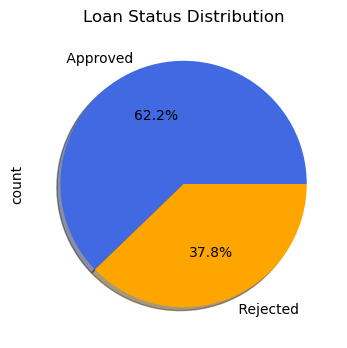

In [11]:
# Loan Status Distribution
plt.figure(figsize = (5,4))
df['loan_status'].value_counts().plot(kind = 'pie', autopct = "%1.1F%%", shadow = True, colors = ['royalblue', 'orange'])
plt.title('Loan Status Distribution')
plt.show()

### **Loan Status Distribution**

**The pie chart shows that ***62.2%*** of loan applications were approved, while ***37.8%*** were rejected. This indicates that approved loans form the majority class in the dataset.**

#### **Key Insight:** 
**The dataset is moderately imbalanced, which may cause machine learning models to favor the approved class during prediction.**

#### **Class Imbalance Handling:** 
**To address this issue, oversampling and undersampling techniques were applied in later stages to create a balanced dataset and improve model performance.**

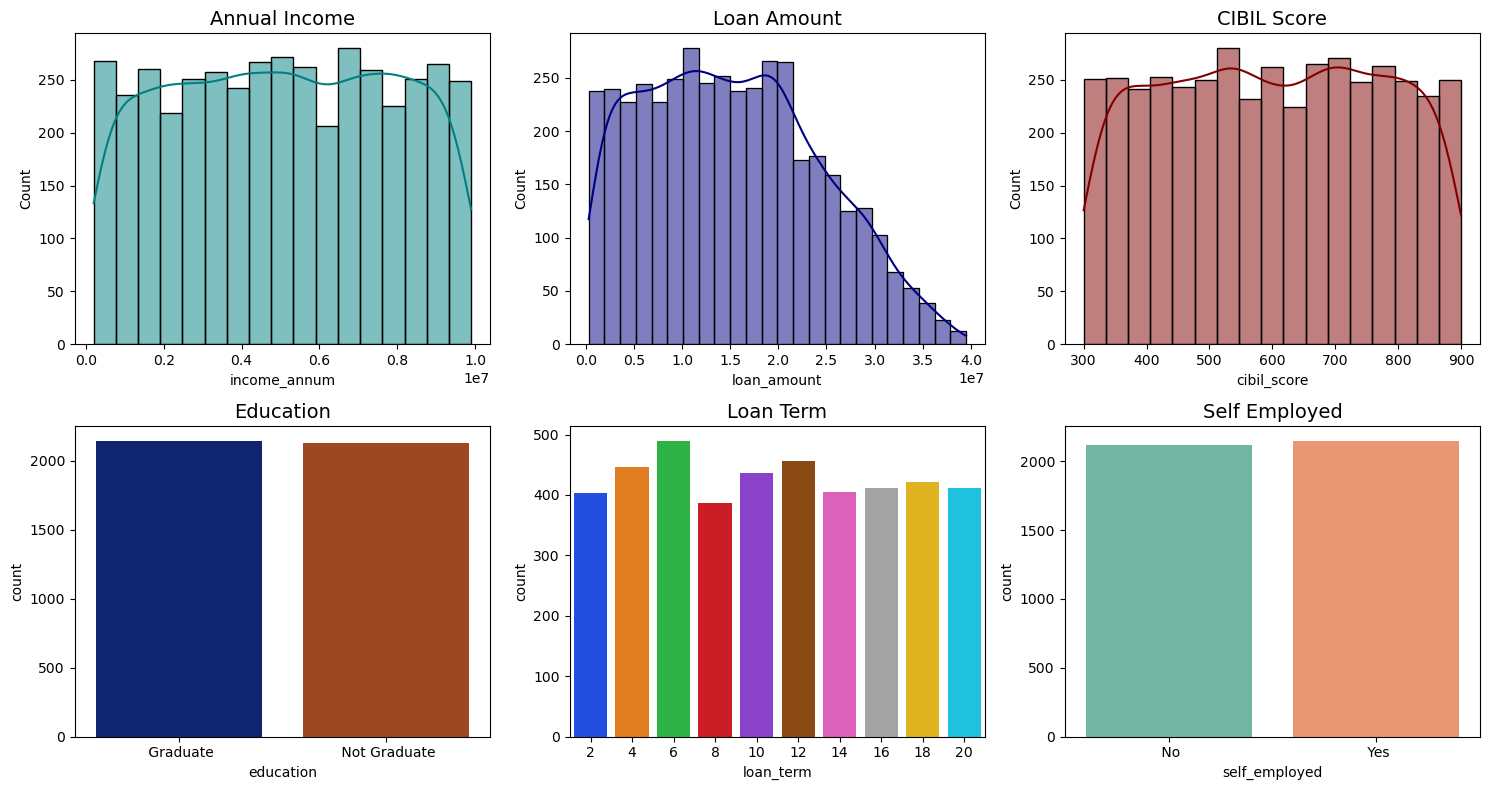

In [12]:
# Distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
sns.histplot(df['income_annum'], kde=True, ax=axes[0,0], color = 'teal'); axes[0,0].set_title('Annual Income', fontsize = '14')
sns.histplot(df['loan_amount'], kde=True, ax=axes[0,1], color = 'navy'); axes[0,1].set_title('Loan Amount', fontsize = '14')
sns.histplot(df['cibil_score'], kde=True, ax=axes[0,2], color = 'maroon'); axes[0,2].set_title('CIBIL Score', fontsize = '14')
sns.countplot(x='education', data=df, ax=axes[1,0], palette = 'dark'); axes[1,0].set_title('Education', fontsize = '14')
sns.countplot(x='loan_term', data=df, ax=axes[1,1], palette = 'bright'); axes[1,1].set_title('Loan Term', fontsize = '14')
sns.countplot(x='self_employed', data=df, ax=axes[1,2], palette = 'Set2'); axes[1,2].set_title('Self Employed', fontsize = '14')
plt.tight_layout()
plt.show()

### **Key Observations from Univariate Analysis**
#### **Annual Income Distribution -**
**The annual income is fairly normally distributed with a slight right skew. Most applicants have income between ₹20 lakh to ₹80 lakh. There is a peak around ₹50-60 lakh, indicating a large middle-income group applying for loans.**
#### **Loan Amount Distribution -**
**Loan amounts show a right-skewed distribution. Most loans are in the range of ₹50 lakh to ₹2 crore, with very few loans above ₹3 crore. This suggests the bank mostly approves moderate-sized loans.**
#### **CIBIL Score Distribution -**
**CIBIL scores are widely spread between 300–900. There is a noticeable concentration of applicants in the 500–700 range, with fewer people having very high scores (>750). This indicates a mix of creditworthy and risky applicants.**
#### **Education Distribution -**
**The dataset is almost balanced between Graduate and Not Graduate applicants (roughly 50-50 split). Education level is evenly distributed among loan applicants.**
#### **Loan Term Distribution -**
**Loan terms range from 2 to 20 years. The most common terms are 6, 12, and 18 years. There is no strong dominant term, showing varied loan duration preferences.**
#### **Self Employed Distribution -**
**The number of Self-Employed and Non-Self-Employed applicants is nearly equal. This balanced distribution means employment type is well represented in the dataset.**

###  **Bivariate Analysis**
**Bivariate Analysis examines the relationship between two variables. In this project, the relationship between different applicant features and the loan approval status is analyzed to identify factors that influence loan approval decisions.**

**Various visualizations such as count plots, box plots, and comparative charts help reveal patterns, trends, and associations between variables and the target variable (Loan Status).**

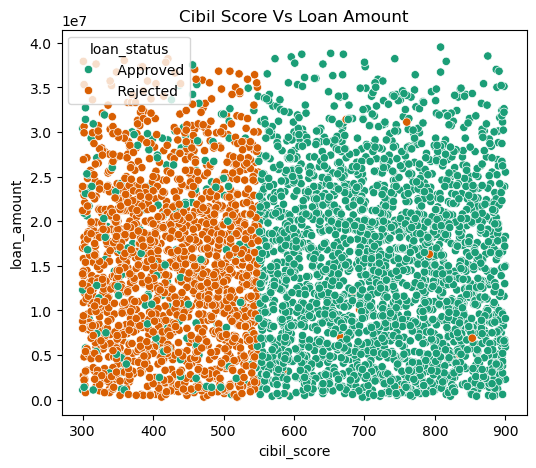

In [13]:
# Cibil Score Vs Loan Status
plt.figure(figsize = (6,5))
sns.scatterplot(data = df , x = 'cibil_score', y = 'loan_amount', hue = 'loan_status',palette = 'Dark2')
plt.title("Cibil Score Vs Loan Amount")
plt.show()

### **CIBIL Score vs Loan Amount**

**The scatter plot shows a clear separation between approved and rejected loans based on *CIBIL score*. Most rejected applications have CIBIL scores below *550*, while approved applications are concentrated above this threshold.**

#### **Key Insight:** 
**CIBIL score appears to be a strong factor in loan approval decisions. Applicants with higher credit scores are more likely to have their loans approved, regardless of the loan amount requested.**

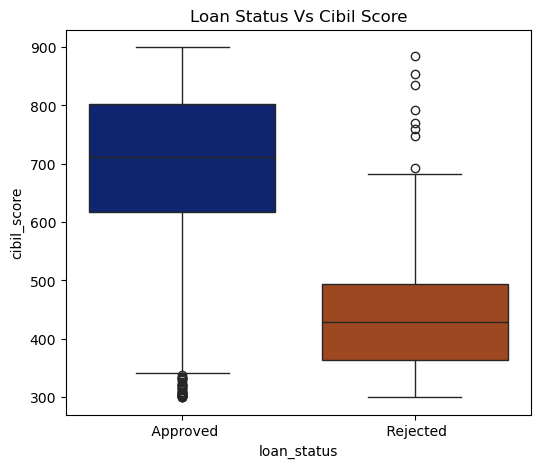

In [14]:
plt.figure(figsize = (6,5))
sns.boxplot(x='loan_status',y='cibil_score',data=df, palette = 'dark')
plt.title('Loan Status Vs Cibil Score' )
plt.show()

### Loan Status vs CIBIL Score

**The box plot shows a significant difference in CIBIL scores between approved and rejected loan applications. Approved loans have a much higher median CIBIL score (around 710) compared to rejected loans (around 430).**

#### **Key Insight:**  
**Applicants with higher CIBIL scores are considerably more likely to receive loan approval. This indicates that CIBIL score is one of the most influential features in the loan approval process.**

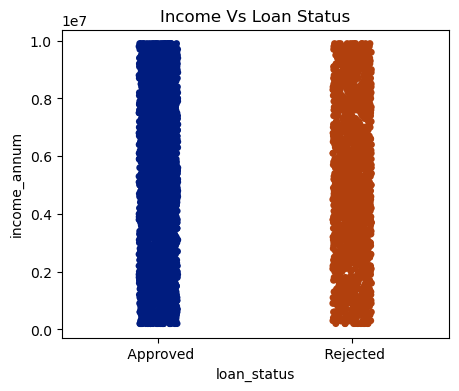

In [15]:
# Income Vs Loan Status
plt.figure(figsize = (5,4))
sns.stripplot(data = df , y = 'income_annum', x = 'loan_status', palette = 'dark')
plt.title("Income Vs Loan Status")
plt.show()

### **Income vs Loan Status**

**The scatter plot shows that both approved and rejected loans are distributed across a wide range of income levels, with significant overlap between the two categories.**

#### **Key Insight:** 
**Income alone does not clearly distinguish approved and rejected loan applications. Other factors, such as CIBIL score, loan amount, and asset value, likely play a more important role in the loan approval decision.**

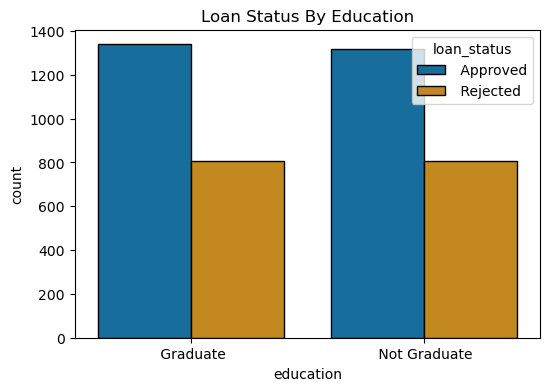

In [16]:
plt.figure(figsize = (6,4))
sns.countplot(data = df , x = 'education', hue = 'loan_status', palette = 'colorblind', edgecolor = 'k')
plt.title('Loan Status By Education')
plt.show()

### **Loan Status vs Education**

**The bar chart shows almost no difference in loan approval patterns between Graduate and Not Graduate applicants. Both groups have nearly the same number of approved and rejected loans.**

#### **Key Insight**

**Education level does not appear to significantly influence loan approval in this dataset. Graduates and non-graduates have almost identical approval rates, suggesting that financial factors such as CIBIL score, income, loan amount, and assets are more important predictors.**



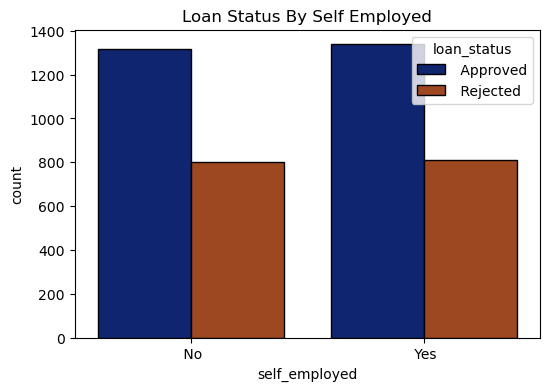

In [17]:
plt.figure(figsize = (6,4))
sns.countplot(data = df , x = 'self_employed', hue = 'loan_status', palette = 'dark', edgecolor = 'k')
plt.title('Loan Status By Self Employed')
plt.show()

### **Loan Status vs Self-Employment**

**The bar chart shows very similar approval and rejection counts for both self-employed and non-self-employed applicants. The difference between the two groups is minimal.**

### **Key Insight**

**Self-employment status does not have a strong impact on loan approval in this dataset. Both self-employed and salaried applicants have nearly the same approval rates, indicating that employment type is less influential than financial and credit-related factors.**

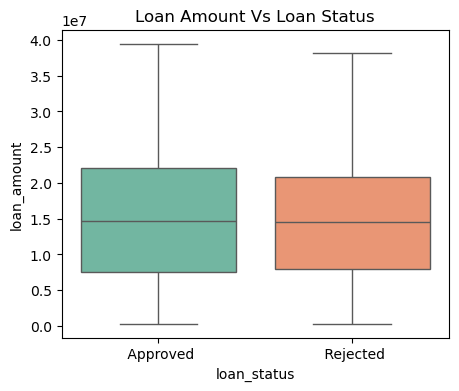

In [18]:
# Income Vs Loan Status
plt.figure(figsize = (5,4))
sns.boxplot(data = df , y = 'loan_amount', x = 'loan_status', palette = 'Set2')
plt.title("Loan Amount Vs Loan Status")
plt.show()

### **Loan Amount vs Loan Status**

**The box plot compares the distribution of loan amounts for approved and rejected loan applications. Both groups have very similar median loan amounts and overlapping distributions, indicating that approved and rejected applicants request comparable loan amounts.**

#### **Key Insight**

**Loan amount alone does not strongly determine whether a loan is approved or rejected. Since the distributions of approved and rejected loans are highly similar, the bank likely considers additional factors such as CIBIL score, income, loan term, and asset values when making approval decisions. However, loan amount may still contribute to the final decision when combined with other financial indicators.**


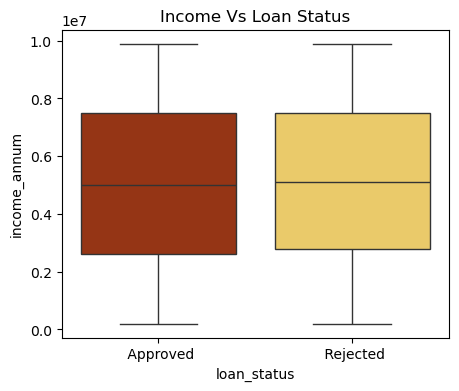

In [19]:
# Income Vs Loan Status
plt.figure(figsize = (5,4))
sns.boxplot(data = df , y = 'income_annum', x = 'loan_status', palette = 'afmhot')
plt.title("Income Vs Loan Status")
plt.show()

### **Income vs Loan Status**

**The box plot shows that approved applicants have a slightly higher median income than rejected applicants. However, there is considerable overlap between the two groups.**

#### **Key Insight:**
**Higher income may improve the chances of loan approval, but income alone is not a decisive factor. Other features such as CIBIL score and assets likely play a more significant role in the approval process.**

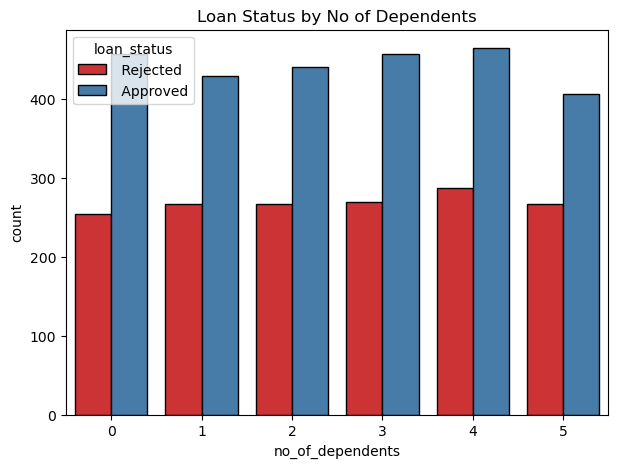

In [20]:
plt.figure(figsize = (7,5))
sns.countplot(data = df , x = 'no_of_dependents', hue = 'loan_status', palette = 'Set1', edgecolor = 'k')
plt.title('Loan Status by No of Dependents')
plt.show()

### **Loan Status vs Number of Dependents**

**The bar chart compares loan approval and rejection counts across different numbers of dependents. For every dependent category, the number of approved loans is noticeably higher than the number of rejected loans. However, the approval and rejection patterns remain fairly consistent across all groups.**

#### **Key Insight:**
**The number of dependents does not appear to have a strong influence on loan approval decisions. Applicants with different numbers of dependents show similar approval rates, suggesting that financial factors such as CIBIL score, income, and assets play a more important role in determining loan approval.**

### **Multivariate Analysis**
**Multivariate Analysis examines the relationships among multiple variables simultaneously. It helps identify how different features interact with each other and collectively influence the target variable, Loan Status.**

**Techniques such as correlation heatmaps and pair plots provide deeper insights into feature relationships, dependencies, and patterns that may not be visible through univariate or bivariate analysis alone.**

In [21]:
from sklearn.preprocessing import LabelEncoder

temp = df.copy()

le = LabelEncoder()

for col in temp.select_dtypes(include='object'):
    temp[col] = le.fit_transform(temp[col])

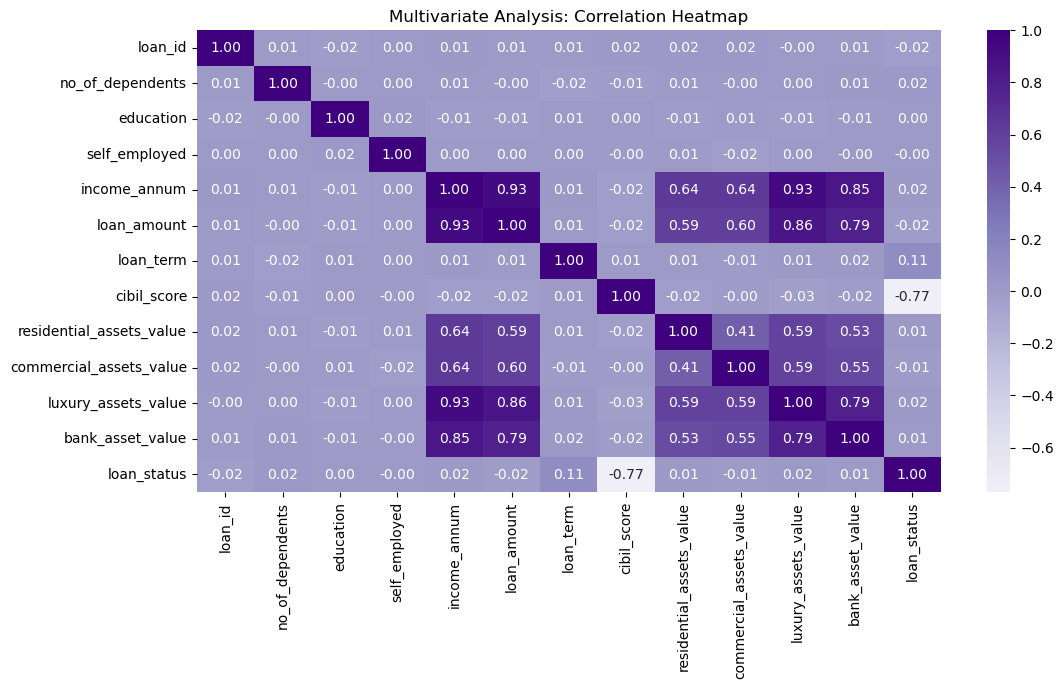

In [22]:
plt.figure(figsize=(12,6))

sns.heatmap(temp.corr(),annot=True,cmap='Purples',fmt='.2f',center=0)
plt.title('Multivariate Analysis: Correlation Heatmap')

plt.show()

### **Correlation Heatmap**

**The correlation heatmap illustrates the relationships between numerical features in the dataset. Correlation values range from -1 to +1, where values closer to +1 indicate a strong positive relationship, values closer to -1 indicate a strong negative relationship, and values near 0 indicate little or no relationship.**

#### **Key Insight:**

- **CIBIL Score shows the strongest relationship with loan status (-0.77), indicating that it is one of the most influential factors in loan approval decisions.**
- **Income, Loan Amount, and Asset Values are strongly correlated with each other, suggesting that applicants with higher incomes tend to possess higher-valued assets and qualify for larger loans.**
- **Features such as Education, Self-Employment, and Number of Dependents show very weak correlations with loan status, indicating a limited impact on loan approval.**

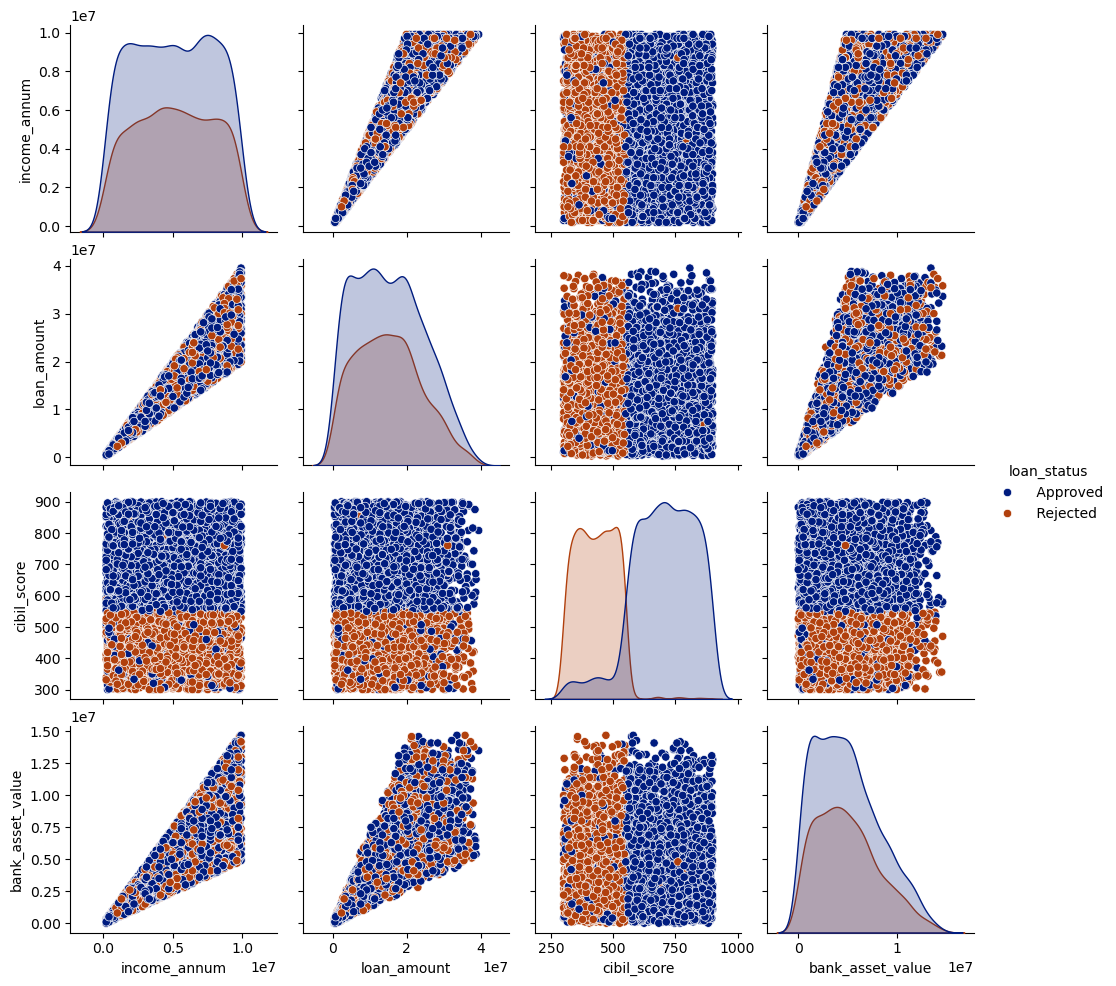

In [23]:
cols = ['income_annum', 'loan_amount','cibil_score', 'bank_asset_value','loan_status']

sns.pairplot(df[cols], hue='loan_status',palette='dark')

plt.show()

### **Pair Plot Analysis**

**The pair plot visualizes the relationships among key numerical features and shows how approved and rejected loan applications are distributed across different variables.**

#### **Key Insight:**

- **CIBIL Score provides the clearest separation between approved and rejected loans. Most approved applications are concentrated at higher CIBIL scores, while rejected applications are concentrated at lower scores.**
- **Income, Loan Amount, and Bank Asset Value show positive relationships with each other, indicating that applicants with higher incomes tend to have larger assets and loan amounts.**
- **Considerable overlap exists between approved and rejected applications for income and loan amount, suggesting that these features alone are not sufficient to determine loan approval.**

## Insights from EDA

**Based on the exploratory data analysis, the following insights were observed:**

### 1. Factors affecting loan approval

**The analysis shows that **CIBIL score, annual income, loan amount, and asset values** are the most influential factors affecting loan approval decisions. Among these, CIBIL score shows the strongest relationship with loan approval status.**

### 2. Impact of CIBIL Score

**A higher CIBIL score significantly increases the chances of loan approval. Applicants with higher credit scores were mostly associated with approved loans, indicating that credit history plays an important role in evaluating an applicant's reliability.**

### 3. Impact of Income

**Income alone does not completely determine loan approval, as approved and rejected applications were observed across different income ranges. However, higher income can improve approval chances by indicating better repayment capacity when combined with other factors.**

### 4. Impact of Assets

**Applicants with higher asset values generally showed better approval chances. Assets provide additional financial security to lenders and reduce the risk associated with loan approval.**

### Overall Insight

**EDA revealed that loan approval decisions depend on multiple factors rather than a single feature. CIBIL score, financial stability, and asset ownership together play an important role in determining loan approval outcomes.**

## **Data Preprocessing**
**Data preprocessing transforms the raw dataset into a format suitable for machine learning models. This stage improves data quality, ensures consistency, and prepares the dataset for accurate prediction.**

In [24]:
#  Loading Libraries for Data Encoding
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Loading Train Test Split for Data Spliting
from sklearn.model_selection import train_test_split as split

# Libraries for handling Imbalance Data

from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler


### **Importing Libraries for Data Preprocessing**

**The required libraries are imported to perform data encoding, feature scaling, dataset splitting, and handling class imbalance.**

- **LabelEncoder is used to convert categorical variables into numerical values.**
- **StandardScaler is used to normalize numerical features by bringing them to a common scale.**
- **train_test_split is used to divide the dataset into training and testing sets for model evaluation.**
- **RandomOverSampler is used to increase the number of samples in the minority class.**
- **RandomUnderSampler is used to reduce the number of samples in the majority class.**



#### **Remove Unnecessary Column**
**Loan ID is not useful for predicting loan approval**

In [25]:
df = df.drop(['loan_id'], axis = 1)

#### **Data Encoding**
**Encoding: Converting categorical variables into numerical values so that machine learning algorithms can process them.**

In [26]:
le = LabelEncoder()

df['education'] = le.fit_transform(df['education'])
df['self_employed'] = le.fit_transform(df['self_employed'])
df['loan_status'] = le.fit_transform(df['loan_status'])

In [27]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1


Data Spliting

### **Splitting the Dataset into Features and Target Variable**

**The dataset is divided into two parts:**

- **X (Features): Contains all independent variables used to predict loan approval.**
- **Y (Target Variable): Contains the loan status, which indicates whether a loan is approved or rejected.**

In [28]:
x = df.drop(columns = ['loan_status'])
y = df['loan_status']

### **Train-Test Split**

**The dataset is further divided into training and testing sets. The training set is used to train the machine learning models, while the testing set is used to evaluate their performance on unseen data.**

In [29]:
Xtrain, Xtest, Ytrain, Ytest = split(x, y,test_size=0.2,random_state=42)

#### **Imbalanced Data Handling**

**The target variable contains an unequal distribution of approved and rejected loan applications, which can lead to biased model predictions. To address this issue, both Random Oversampling and Random Undersampling techniques are applied to the training dataset.**

- **Random Oversampling increases the number of samples in the minority class by duplicating existing observations until both classes are balanced.**
- **Random Undersampling reduces the number of samples in the majority class by randomly removing observations to achieve class balance.**

**Using both techniques allows a comparison of model performance under different balancing strategies and helps identify the most effective approach for loan approval prediction.**



##### Applying Over Sampling

##### Increases the number of samples in the minority class.

In [30]:
# Creating an object to store RandomOverSampler
ros = RandomOverSampler(random_state = 42)

# resampling the training dataset
X_train_ros, y_train_ros = ros.fit_resample(Xtrain, Ytrain)


In [31]:
# Cheacking the values
y_train_ros.value_counts()

loan_status
0    2120
1    2120
Name: count, dtype: int64

**Appling Under Sampling**
**Reduces the number of samples in the majority class**

In [32]:
# Creating an object to store RandomUnderSampler
rus = RandomUnderSampler(random_state = 42)

# resampling the training dataset
X_train_rus, y_train_rus = rus.fit_resample(Xtrain, Ytrain)


In [33]:
# Cheacking the values
y_train_rus.value_counts()

loan_status
0    1295
1    1295
Name: count, dtype: int64

**Outcome:**
**Two balanced training datasets are created using oversampling and undersampling. These datasets help reduce class bias and improve the ability of machine learning models to accurately predict both approved and rejected loan applications.**

#### **Data Normalization**
**Feature scaling is performed to ensure that all numerical features contribute equally during model training. Since different features have different value ranges, standardization transforms them to a common scale with a mean of 0 and a standard deviation of 1.**

**The scaler is fitted on the oversampled training data and then applied to the undersampled training data and test data using the same transformation. This maintains consistency across all datasets and prevents data leakage.**

In [34]:
# Applying Standarrd scaler to input data
scaler = StandardScaler()

X_train_ros = scaler.fit_transform(X_train_ros)
X_train_rus = scaler.transform(X_train_rus)
Xtest = scaler.transform(Xtest)

In [35]:
print('Over Sampled Traing Data : \n ',X_train_ros[:2])
print('Under Sampled Traing Data : \n ',X_train_rus[:2])
print('Testing data : \n ',Xtest[:2])

Over Sampled Traing Data : 
  [[ 1.51410766  1.00047181 -1.01329593  1.01375936  1.63463661 -0.89636946
   0.0035477  -0.2534959   2.06126999  0.07706343  1.16596332]
 [-1.44569708  1.00047181  0.98687853  1.62253863  2.0891279   0.16249194
   0.82666977  2.4974045   1.23741184  2.51139686  0.88680631]]
Under Sampled Traing Data : 
  [[-0.26177518  1.00047181 -1.01329593 -0.27542025 -0.07247703 -0.19046186
   0.1542602   0.60233978 -0.95954323 -0.13128042  0.11137018]
 [-0.85373613 -0.99952841  0.98687853  0.61984337  0.85867586 -0.89636946
   0.04992078 -1.06348325  1.42049143 -0.15321135  0.20442252]]
Testing data : 
  [[ 1.51410766 -0.99952841 -1.01329593  0.11849574  0.50395095  1.57430713
  -0.83696427 -0.14651644  1.16875699  0.0551325   0.73171909]
 [-0.26177518 -0.99952841 -1.01329593  0.29754847 -0.1279028  -0.54341566
   0.18324337 -0.42160649  1.05433225  0.28540728  0.54561442]]


## Model Building and Evaluation 

### **Importing Machine Learning Models and Evaluation Metrics**

**The required machine learning algorithms are imported to build and compare different loan approval prediction models. Multiple models are used to evaluate which algorithm performs best on the dataset.**

**The following models are included:**

- **Logistic Regression for linear classification.**
- **Decision Tree Classifier for rule-based decision making.**
- **Random Forest Classifier for ensemble learning and improved prediction accuracy.**
- **Support Vector Classifier (SVC) for classification using optimal decision boundaries.**

**To assess model performance, various evaluation metrics are imported:**

- **Accuracy Score measures overall prediction correctness.**
- **Precision Score measures the proportion of correct positive predictions.**
- **Recall Score measures the model's ability to identify actual positive cases.**
- **F1 Score provides a balance between precision and recall.**
- **Confusion Matrix summarizes correct and incorrect predictions.**



In [36]:
# Import Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Import Model Evaluation Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [37]:
# Dictionary containing all models
models = {
    "Logistic Regression": LogisticRegression(random_state=42,max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42,n_estimators=100),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVC": SVC(random_state=42)
}

In [38]:
# Dictionary containing oversampled and undersampled datasets
datasets = {
    "Oversampling": (X_train_ros, y_train_ros),
    "Undersampling": (X_train_rus, y_train_rus)
}


In [39]:
# Empty list to store evaluation results
results = []

In [40]:
# Loop through each sampling technique
for sampling_name, (X_train_sample, y_train_sample) in datasets.items():

    # Loop through each model
    for model_name, model in models.items():

        # Train the model
        model.fit(X_train_sample, y_train_sample)

        # Predict on test data
        y_pred = model.predict(Xtest)

        # Store model performance metrics
        results.append({

            "Sampling": sampling_name,
            "Model": model_name,
            "Accuracy": accuracy_score(Ytest, y_pred),
            "Precision": precision_score(Ytest, y_pred),
            "Recall": recall_score(Ytest, y_pred),
            "F1 Score": f1_score(Ytest, y_pred)
        })

In [41]:
# Convert results list into DataFrame
results_df = pd.DataFrame(results)

In [42]:
# Sort models by highest accuracy
results_df.sort_values(
    by="Accuracy",
    ascending=False,
    inplace=True)


In [43]:
# Display comparison table
results_df

,Sampling,Model,Accuracy,Precision,Recall,F1 Score
1,Oversampling,Random Forest,0.978923,0.974684,0.968553,0.971609
2,Oversampling,Decision Tree,0.978923,0.971698,0.971698,0.971698
5,Undersampling,Random Forest,0.976581,0.954268,0.984277,0.969040
6,Undersampling,Decision Tree,0.976581,0.962733,0.974843,0.968750
3,Oversampling,SVC,0.927400,0.855556,0.968553,0.908555
0,Oversampling,Logistic Regression,0.911007,0.847701,0.927673,0.885886
7,Undersampling,SVC,0.911007,0.821809,0.971698,0.890490
4,Undersampling,Logistic Regression,0.907494,0.844380,0.921384,0.881203


### **Model Training and Performance Evaluation**

**A loop is used to train multiple machine learning models on both oversampled and undersampled datasets. Each trained model makes predictions on the test dataset, and its performance is evaluated using various classification metrics.**

**The evaluation metrics include:**

**Accuracy – Measures the overall correctness of predictions.
Precision – Measures how many predicted approvals are actually correct.
Recall – Measures the model's ability to identify actual approved loans.
F1 Score – Provides a balanced measure of precision and recall.**

**The performance of each model is stored for comparison, allowing the identification of the most effective model and sampling technique for loan approval prediction.**

In [44]:
# Best Model
best_model = results_df.iloc[0]

print(best_model)

Sampling      Oversampling
Model        Random Forest
Accuracy          0.978923
Precision         0.974684
Recall            0.968553
F1 Score          0.971609
Name: 1, dtype: object


**Among all model and sampling combinations, the Random Forest Classifier trained on the oversampled dataset achieved the best overall performance. The model obtained an Accuracy of 97.89%, Precision of 97.47%, Recall of 96.86%, and an F1-Score of 97.16%. These results indicate excellent predictive capability and balanced classification performance. Therefore, the Oversampled Random Forest model was selected as the final model for loan approval prediction.**

### **Training the Best Performing Model**

**Based on the comparison of all machine learning models, the Random Forest Classifier is selected as the best-performing model. The model is trained using the balanced dataset created through undersampling and then used to make predictions on the test dataset.**

**Random Forest combines multiple decision trees to improve prediction accuracy and reduce the risk of overfitting, making it highly effective for classification tasks.**

In [45]:
best_model = RandomForestClassifier(random_state=42)

best_model.fit(X_train_ros, y_train_ros)

y_pred = best_model.predict(Xtest)

In [46]:
print(classification_report(y_pred,Ytest))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98       538
           1       0.97      0.97      0.97       316

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



## **Classification Report of Final Random Forest Model**

**The classification report evaluates the performance of the final **Oversampled Random Forest Classifier** using precision, recall, F1-score, and accuracy metrics.**

### **Performance Summary:**

- **Class 0 (Approved Loans):**
  - **Precision: 0.99**
  - **Recall: 0.98**
  - **F1-score: 0.98**

- **Class 1 (Rejected Loans):**
  - **Precision: 0.97**
  - **Recall: 0.97**
  - **F1-score: 0.97**

### **Key Insights:**

- **The model achieved an overall **accuracy of 98%**, showing excellent prediction performance.**
- **Both classes achieved high precision and recall values, indicating that the model performs well in identifying approved and rejected loan applications.**
- **The balanced F1-scores demonstrate that the model maintains a good balance between correctly identifying positive and negative cases.**
- **The results confirm that the Oversampled Random Forest model is effective and reliable for loan approval prediction.**

### **Confusion Matrix**

**The confusion matrix provides a detailed summary of the model's prediction performance by comparing actual loan statuses with predicted loan statuses. It shows the number of correctly and incorrectly classified loan applications.**

- **True Positives (TP): Correctly predicted approved loans.**
- **True Negatives (TN): Correctly predicted rejected loans.**
- **False Positives (FP): Rejected loans incorrectly predicted as approved.**
- **False Negatives (FN): Approved loans incorrectly predicted as rejected.**

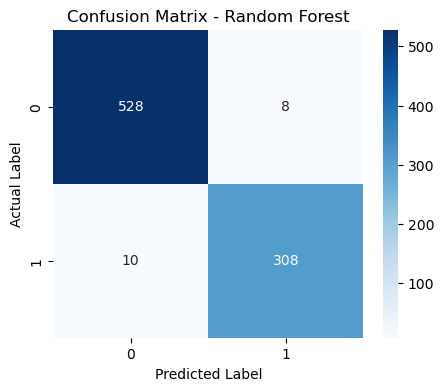

In [47]:
# Confusion Matrix
cm = confusion_matrix(Ytest, y_pred)

# Plot
plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True,fmt='d',cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Random Forest")

plt.show()



**The Random Forest model correctly classified 528 positive cases and 308 negative cases. Only 8 positive cases were incorrectly classified as negative, and 10 negative cases were incorrectly classified as positive. The low number of misclassifications demonstrates the effectiveness of the Oversampled Random Forest model in accurately predicting loan approval status.**

### **Feature Importance Analysis**
**Feature Importance Analysis identifies the contribution of each feature to the model's predictions. The Random Forest model assigns an importance score to every feature based on how much it helps in making accurate loan approval decisions.**

**The features are sorted in descending order of importance, allowing the most influential factors to be identified easily.**

In [48]:
importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': best_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

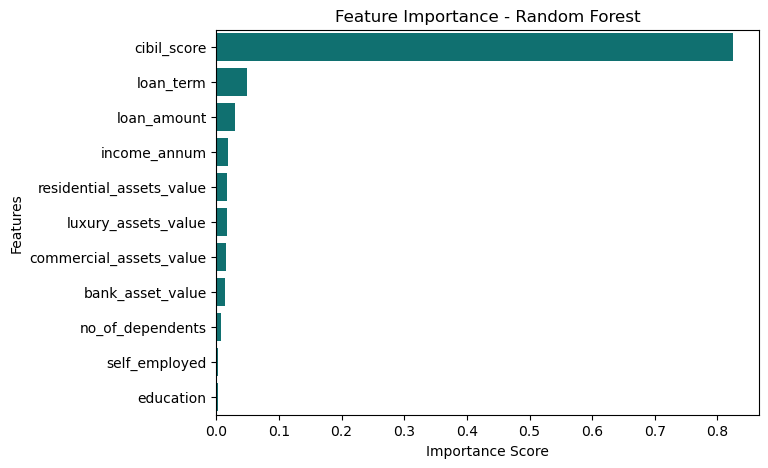

In [49]:
plt.figure(figsize=(7,5))

sns.barplot(data=importance,x='Importance',y='Feature', color = 'teal')
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

**Feature Importance analysis was performed using the Random Forest model to identify the most influential factors affecting loan approval. The results indicate that CIBIL Score is the most important feature, contributing more than 80% of the model's decision-making power. This suggests that an applicant's credit history plays a crucial role in loan approval decisions.**

 **Other important features include Loan Term, Loan Amount, Residential Assets Value, Luxury Assets Value, Commercial Assets Value, and Annual Income, although their impact is significantly lower than that of the CIBIL Score.**

 **Features such as Education, Self-Employment Status, and Number of Dependents have very low importance, indicating that they contribute minimally to the model's predictions.**

## **Conclusion**
**This project successfully demonstrates the application of Machine Learning techniques to predict loan approval decisions in the banking sector. Through systematic dataset understanding, comprehensive Exploratory Data Analysis (EDA), careful data preprocessing, and rigorous model development, we were able to build an accurate and interpretable predictive system.
Key Findings from EDA.**

- **CIBIL Score emerged as the most influential factor in loan approval. Applicants with higher CIBIL scores (especially above 700) have a significantly higher probability of approval, highlighting the critical role of credit history in banking decisions.**
- **Annual Income, Loan Amount, and various asset values (Residential, Luxury, and Commercial) also show a positive correlation with loan approval, though their impact is considerably lower than CIBIL Score.**
- **Graduates have a moderately higher approval rate compared to Non-Graduates, indicating that education level provides some predictive value.
Self-employment status and number of dependents showed relatively weak influence on loan outcomes.**

### **Best Performing Model**
**Among the evaluated models — Logistic Regression, Decision Tree, and Random Forest — the Random Forest Classifier trained on the oversampled dataset achieved the best performance.**

**The model obtained:**
- **Accuracy: 97.89%**
- **Precision: 97.47%**
- **Recall: 96.86%**
- **F1-Score: 97.16%**

**These results demonstrate that the Oversampled Random Forest model provides excellent classification performance and was selected as the final model for loan approval prediction.**

**The model demonstrated excellent capability in distinguishing between approved and rejected loan applications with minimal false positives and negatives.**
### **Feature Importance**
**Feature importance analysis using Random Forest confirmed that CIBIL Score dominates the decision-making process (contributing over 80% of the model’s predictive power). Other notable features include Loan Term, Loan Amount, and Asset values. Factors such as Education, Self-Employed status, and Number of Dependents had minimal contribution.**
### **Key Findings**

- **Domain knowledge (importance of credit score) was strongly validated through data-driven analysis.**
- **Tree-based ensemble models like Random Forest are highly effective for tabular financial datasets.**
- **Thorough EDA and feature importance analysis are essential not just for performance but also for model interpretability — a critical requirement in the banking industry.**
- **Balancing statistical performance with business insights leads to more trustworthy and deployable solutions.**

**This project highlights how Machine Learning can assist financial institutions in making faster, more consistent, and data-driven loan approval decisions while reducing manual effort and potential bias.**
### **Future Scope:**
**Developing a user-friendly Streamlit web application for real-time predictions and exploring advanced techniques like XGBoost, SHAP explainability, and class imbalance handling can further enhance the system.**